# Stellar Luminosity — Linear & Polynomial Regression from First Principles

**Driving question:** *How does a regression model learn from data?*

We build, train, compare and interpret two regression models on stellar **mass vs luminosity**,
using **NumPy + Matplotlib only**. Everything (prediction, error, gradients, gradient descent)
is written by hand.

**Convention (same as the workshop notebooks):**
- Model: $\hat{y} = Xw + b$
- Cost: $J(w,b) = \frac{1}{2m}\sum_i(\hat{y}^{(i)}-y^{(i)})^2$
- Gradients: $\partial J/\partial w = \frac{1}{m}X^{T}e$, $\;\partial J/\partial b = \frac{1}{m}\sum_i e^{(i)}$, with $e=\hat{y}-y$.

## 1. Environment & data

In [1]:
import platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("Python:", platform.python_version(), "| NumPy:", np.__version__, "| Matplotlib:", matplotlib.__version__)

mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

print("shapes:", mass.shape, luminosity.shape, "| m =", mass.shape[0])
print(f"mass range [{mass.min()}, {mass.max()}] | luminosity range [{luminosity.min()}, {luminosity.max()}]")

Python: 3.13.12 | NumPy: 2.4.4 | Matplotlib: 3.10.8
shapes: (10,) (10,) | m = 10
mass range [0.6, 2.4] | luminosity range [0.15, 35.0]


## 2. Explore before modeling

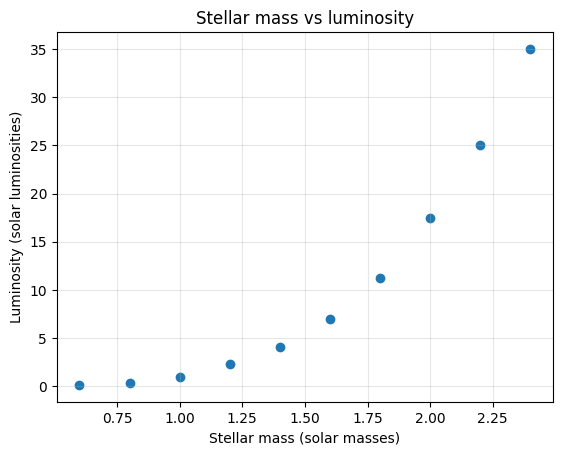

In [2]:
plt.figure()
plt.scatter(mass, luminosity, color="tab:blue")
plt.xlabel("Stellar mass (solar masses)"); plt.ylabel("Luminosity (solar luminosities)")
plt.title("Stellar mass vs luminosity"); plt.grid(True, alpha=0.3); plt.show()

Luminosity grows **super-linearly** with mass (nearly flat at low mass, steeply rising at high
mass). A single straight line cannot follow this curvature: it will over-predict mid-range stars
and under-predict the brightest one, leaving **systematic (patterned) residuals** — classic
underfitting. We expect adding $\text{mass}^2$ to fix this. 

## 3. The learning algorithm (vectorized, works for 1+ features)

In [3]:
def predict(X, w, b):
    """f(X) = X @ w + b.  X:(m,n)  w:(n,)  b:scalar  -> (m,)"""
    return X @ w + b

def compute_cost(X, y, w, b):
    """MSE cost J = (1/2m) * sum(e^2)."""
    m = X.shape[0]; e = predict(X, w, b) - y
    return (e @ e) / (2 * m)

def compute_gradient(X, y, w, b):
    """dj_dw = (1/m) X^T e ;  dj_db = (1/m) sum(e)."""
    m = X.shape[0]; e = predict(X, w, b) - y
    return (X.T @ e) / m, np.sum(e) / m

def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    """Batch GD. Returns learned (w, b) and the cost history."""
    w, b, cost_history = w_init.copy(), b_init, []
    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
    return w, b, np.array(cost_history)

def feature_scale(X):
    """Standardize columns to mean 0 / std 1. Returns X_scaled, means, stds."""
    means, stds = X.mean(axis=0), X.std(axis=0)
    return (X - means) / stds, means, stds

## 4. Linear model — $X = [\,\text{mass}\,]$
One feature on a small range (0.6–2.4), so we train **unscaled** and read $w$=slope, $b$=intercept.

In [4]:
X_linear = mass.reshape(-1, 1)
w_lin, b_lin, cost_hist_lin = gradient_descent(X_linear, luminosity, np.zeros(1), 0.0, 0.1, 20000)
print(f"w (slope) = {w_lin[0]:.4f} | b (intercept) = {b_lin:.4f} | final cost = {cost_hist_lin[-1]:.6f}")

w (slope) = 18.1303 | b (intercept) = -16.8355 | final cost = 9.795148


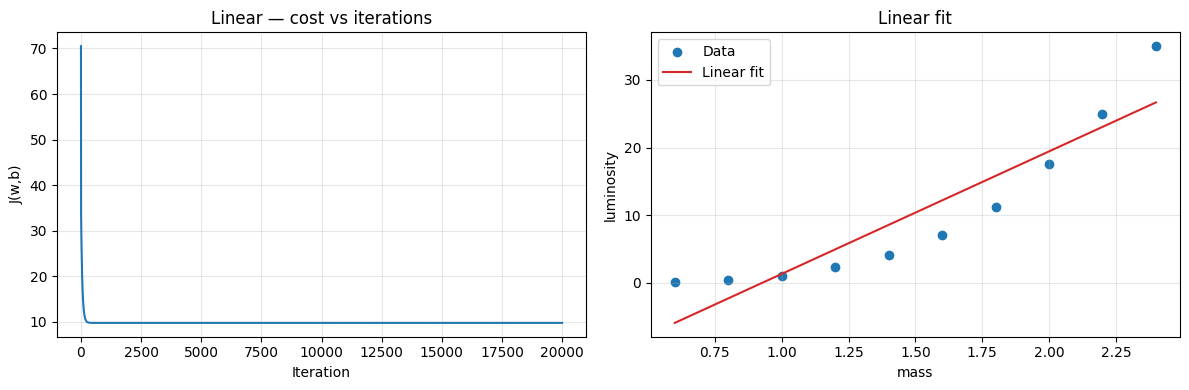

In [5]:
grid = np.linspace(mass.min(), mass.max(), 200).reshape(-1, 1)
y_line = predict(grid, w_lin, b_lin)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cost_hist_lin); ax[0].set_title("Linear — cost vs iterations")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("J(w,b)"); ax[0].grid(True, alpha=0.3)
ax[1].scatter(mass, luminosity, label="Data", color="tab:blue")
ax[1].plot(grid, y_line, label="Linear fit", color="tab:red")
ax[1].set_title("Linear fit"); ax[1].set_xlabel("mass"); ax[1].set_ylabel("luminosity")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Cost decreases monotonically and flattens → GD **converged**. But final cost ≈ 9.8 is high and
the line misses the curvature (even predicting negative luminosity near the intercept). The model
**converged well but underfits** — convergence is about the optimizer, underfitting about the
representation.

## 5. Polynomial model — $X = [\,\text{mass},\ \text{mass}^2\,]$
Still linear in $(w_1,w_2,b)$, so we **reuse the same functions unchanged**. The two columns have
very different scales, so we standardize (preprocessing only — the algorithm is untouched) and keep
means/stds to transform new points identically.

In [6]:
X_poly_raw = np.column_stack([mass, mass**2])
X_poly, poly_means, poly_stds = feature_scale(X_poly_raw)
w_poly, b_poly, cost_hist_poly = gradient_descent(X_poly, luminosity, np.zeros(2), 0.0, 0.3, 20000)
print(f"w_mass = {w_poly[0]:.4f} | w_mass^2 = {w_poly[1]:.4f} | b = {b_poly:.4f} | final cost = {cost_hist_poly[-1]:.6f}")

w_mass = -15.4028 | w_mass^2 = 26.1825 | b = 10.3600 | final cost = 0.315133


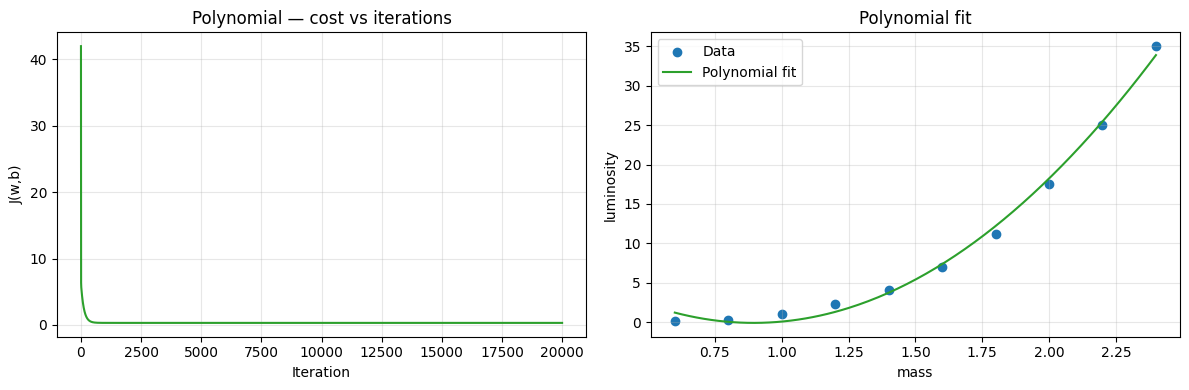

In [7]:
grid_mass = np.linspace(mass.min(), mass.max(), 200)
grid_poly = (np.column_stack([grid_mass, grid_mass**2]) - poly_means) / poly_stds
y_curve = predict(grid_poly, w_poly, b_poly)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cost_hist_poly, color="tab:green"); ax[0].set_title("Polynomial — cost vs iterations")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("J(w,b)"); ax[0].grid(True, alpha=0.3)
ax[1].scatter(mass, luminosity, label="Data", color="tab:blue")
ax[1].plot(grid_mass, y_curve, label="Polynomial fit", color="tab:green")
ax[1].set_title("Polynomial fit"); ax[1].set_xlabel("mass"); ax[1].set_ylabel("luminosity")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Changed:** the representation (added `mass²`), so the hypothesis can bend and cost drops from
~9.8 to ~0.3. **Unchanged:** the learning algorithm — polynomial regression is just linear
regression on engineered features.

## 6. Compare the models

Final cost — linear: 9.795148 | polynomial: 0.315133 | reduction: 31.1x


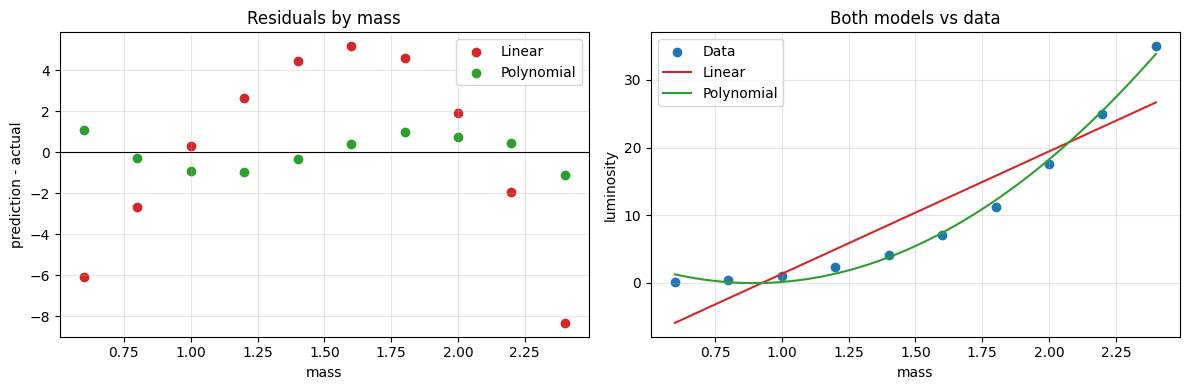

In [8]:
y_pred_lin  = predict(X_linear, w_lin, b_lin)
y_pred_poly = predict(X_poly, w_poly, b_poly)
cost_lin, cost_poly = compute_cost(X_linear, luminosity, w_lin, b_lin), compute_cost(X_poly, luminosity, w_poly, b_poly)
print(f"Final cost — linear: {cost_lin:.6f} | polynomial: {cost_poly:.6f} | reduction: {cost_lin/cost_poly:.1f}x")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(mass, y_pred_lin - luminosity, color="tab:red", label="Linear")
ax[0].scatter(mass, y_pred_poly - luminosity, color="tab:green", label="Polynomial")
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].set_title("Residuals by mass"); ax[0].set_xlabel("mass"); ax[0].set_ylabel("prediction - actual")
ax[0].legend(); ax[0].grid(True, alpha=0.3)
ax[1].scatter(mass, luminosity, label="Data", color="tab:blue")
ax[1].plot(grid, y_line, label="Linear", color="tab:red")
ax[1].plot(grid_mass, y_curve, label="Polynomial", color="tab:green")
ax[1].set_title("Both models vs data"); ax[1].set_xlabel("mass"); ax[1].set_ylabel("luminosity")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Linear residuals form a clear **U-shape** (structured error = underfitting); polynomial residuals
are much smaller and unpatterned, with ~31× lower cost. So the polynomial represents the observed
range better. **But** lower *training* error only means a better fit to these 10 points — it is
**not** proof of the true physical law nor of generalization.

## 7. Test the boundary of the evidence
`mass = 1.3` (inside range) and `mass = 5.0` (far outside).

In [9]:
def predict_linear(mv): return predict(np.array([[mv]]), w_lin, b_lin)[0]
def predict_poly(mv):
    x = (np.array([[mv, mv**2]]) - poly_means) / poly_stds   # same transform as training
    return predict(x, w_poly, b_poly)[0]

for mv in [1.3, 5.0]:
    loc = "inside" if mass.min() <= mv <= mass.max() else "OUTSIDE"
    print(f"mass={mv} ({loc}): linear={predict_linear(mv):8.3f} | polynomial={predict_poly(mv):8.3f}")

mass=1.3 (inside): linear=   6.734 | polynomial=   2.389
mass=5.0 (OUTSIDE): linear=  73.816 | polynomial= 252.390


**mass=1.3 (interpolation):** the polynomial (~2.4) fits its neighborhood (2.30 at 1.2, 4.10 at
1.4); the linear (~6.7) is too high. Reasonable to trust cautiously. **mass=5.0 (extrapolation):**
the models disagree wildly (~74 vs ~252) and *no data supports either* — the `mass²` term now
dominates and explodes. **Neither should be trusted.** A model's reliability is bounded by its
training data; a good fit inside the range says nothing about outside it.

## 8. Reflection on Artificial Intelligence

**8.1 — What this experiment reveals / fails to reveal about how advanced AI learns.**
*Reveals:* the core loop scales up — parameterize a function, measure a loss, follow its gradient
downhill; and **representation** decides what's learnable (one `mass²` feature fixed the model),
mirroring how architecture drives deep learning. *Fails to reveal:* everything hard about large
systems — non-convex losses, billions of parameters, and models that **learn their own features**
instead of us supplying `mass²`. Regression shows the skeleton of learning, not the full picture.

**8.2 — Is AGI achievable?** By AGI I mean a system that learns and performs flexibly across the
broad range of tasks a competent human can, transferring to genuinely novel problems. No physical
law forbids it (brains prove general intelligence is physically possible), so it's plausibly
reachable *in principle*, but with **highly uncertain timelines**; confident predictions either way
have a poor track record. 

**8.3 — Scaling vs new ideas?** Both have evidence. Scaling has repeatedly produced capabilities
skeptics thought needed new ideas; yet gaps persist (sample efficiency, causal reasoning, planning,
grounding through action). Likely scaling is *necessary and productive but maybe not sufficient* —
just as here no amount of gradient descent fixed the linear model; only changing the representation did.

**8.4 — One question I want to explore this semester:**
What is currently being developed in AI, and what might these systems become capable of in the future?